In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

In [73]:
img1 = cv2.imread(r'images\12.jpg', cv2.IMREAD_GRAYSCALE)
img2 = cv2.imread(r'images\13.jpg', cv2.IMREAD_GRAYSCALE)

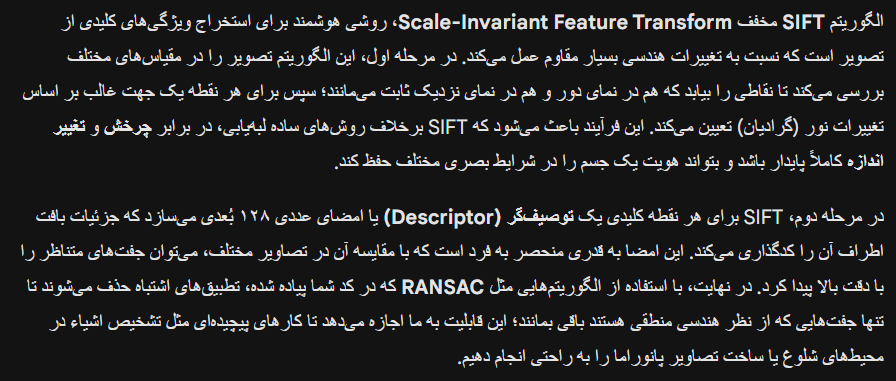

In [74]:
sift = cv2.SIFT_create()


kp1, des1 = sift.detectAndCompute(img1, None)
kp2, des2 = sift.detectAndCompute(img2, None)

In [75]:
print(f"تعداد نقاط یافت شده در تصویر اول: {len(kp1)}")
print(f"تعداد نقاط یافت شده در تصویر دوم: {len(kp2)}")


تعداد نقاط یافت شده در تصویر اول: 1611
تعداد نقاط یافت شده در تصویر دوم: 1616


In [82]:
kp1_sorted = sorted(kp1, key=lambda x: x.response, reverse=True)[:50]
kp2_sorted = sorted(kp2, key=lambda x: x.response, reverse=True)[:50]

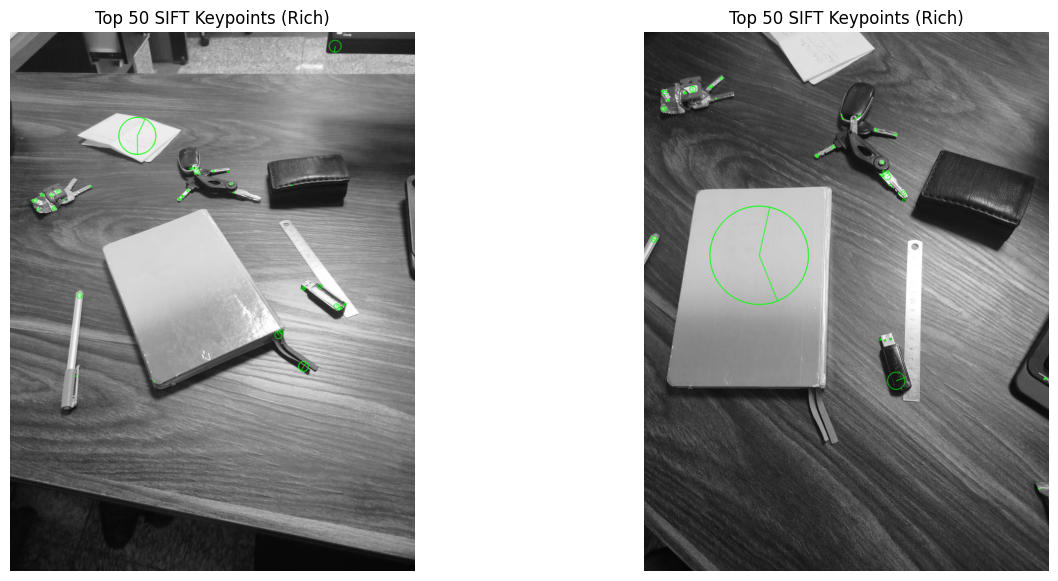

In [83]:
img1_kp = cv2.drawKeypoints(img1, kp1_sorted, None, color=(0, 255, 0),
                            flags=cv2.DrawMatchesFlags_DRAW_RICH_KEYPOINTS)

img2_kp = cv2.drawKeypoints(img2, kp2_sorted, None, color=(0, 255, 0),
                            flags=cv2.DrawMatchesFlags_DRAW_RICH_KEYPOINTS)


plt.figure(figsize=(15, 7))
plt.subplot(1, 2, 1)
plt.imshow(img1_kp)
plt.title('Top 50 SIFT Keypoints (Rich)')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(img2_kp)
plt.title('Top 50 SIFT Keypoints (Rich)')
plt.axis('off')

plt.show()

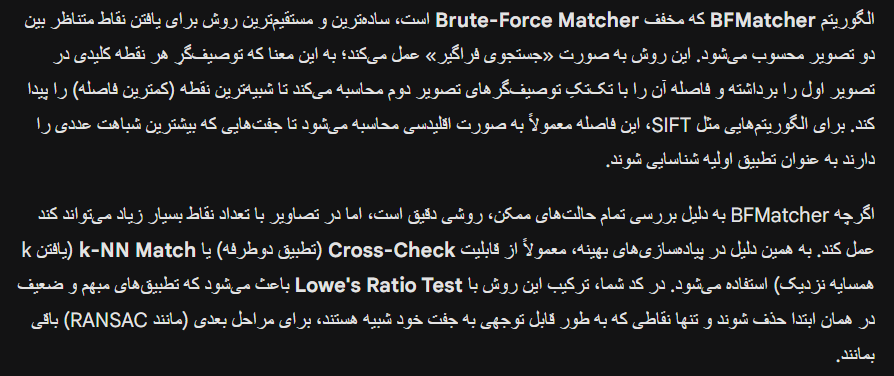

In [78]:
bf = cv2.BFMatcher(cv2.NORM_L2)
matches = bf.knnMatch(des1, des2, k=2)

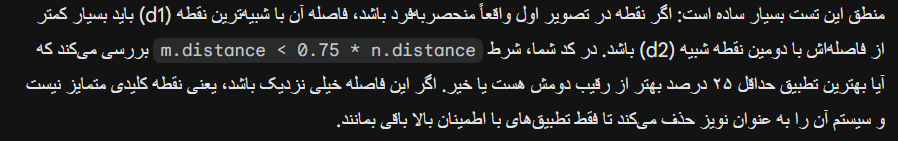

In [79]:
good_matches = []
for m, n in matches:
    if m.distance < 0.75 * n.distance:
        good_matches.append(m)

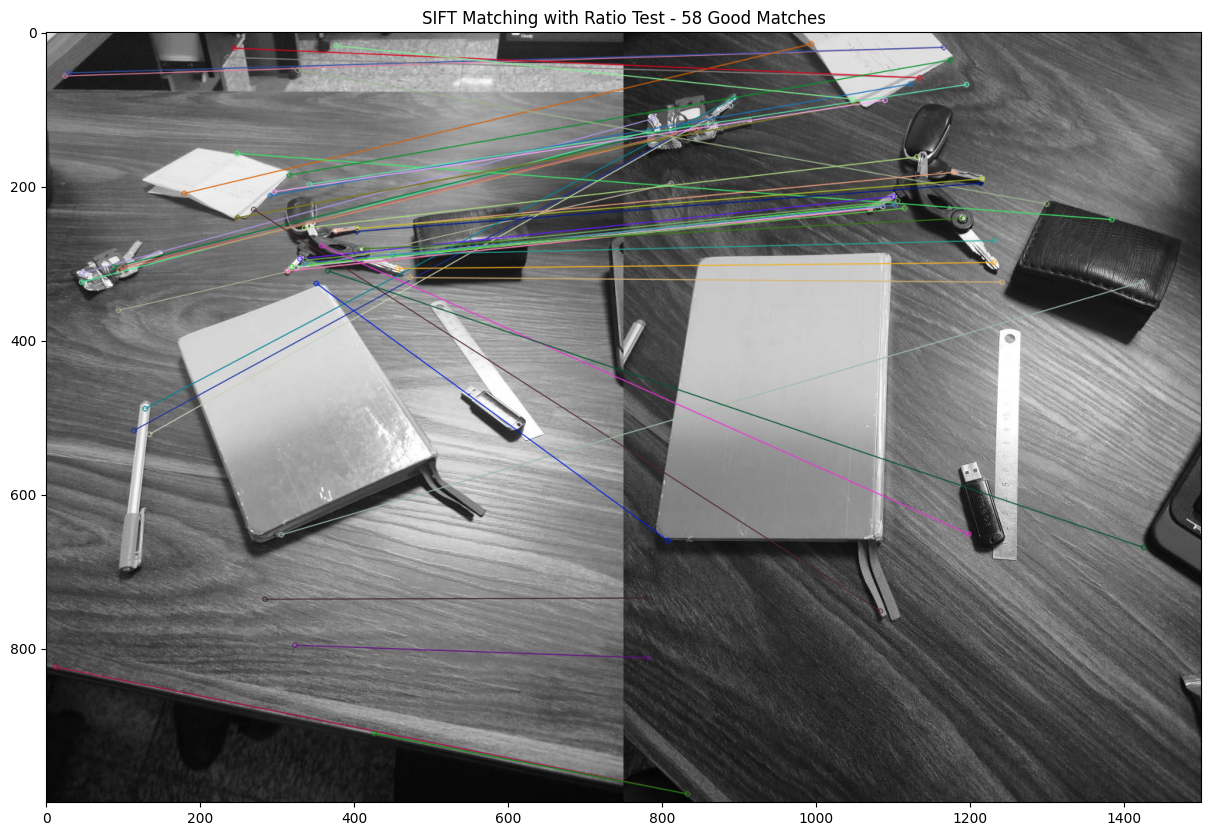

In [81]:
img_result = cv2.drawMatches(img1, kp1, img2, kp2, good_matches[:50], None, 
                             flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)

plt.figure(figsize=(15, 10))
plt.imshow(img_result)
plt.title(f"SIFT Matching with Ratio Test - {len(good_matches)} Good Matches")
plt.show()